# The workbench

One run of this notebook plays one whole activity, from the first call to the last moment, and shows everything each call sends and everything it gets back. It holds no copy of anything: it reads the prompts out of `agents/` and `shared/`, and it makes the calls `panel/devising.py` and `panel/continuing.py` make.

The product repairs, checks and screens without saying so. Each of those has a cell here, in the order the container runs them.

One activity is one activity. Decide here what to try; `python -m research.run` answers whether it worked.

In [1]:
import os
import secrets
import sys
import time
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import research.bench as bench  # noqa: E402
from agents.experience_deviser import ExperienceDeviser, experience_in, the_prompt  # noqa: E402
from orchestrator.router import FoundryConfig, FoundryRouter  # noqa: E402
from orchestrator.safety import (  # noqa: E402
    AzureContentSafetyGate,
    ContentSafetyConfig,
    screen_experience,
)
from shared.agents import AgentContext  # noqa: E402
from shared.ids import LearnerId  # noqa: E402
from shared.seal import Sealer, SealPurpose  # noqa: E402

bench.environment()

# Built exactly as `panel/devising.py` builds it, so the gate and the router here are the
# ones production uses. The safety key is per-process: the seal this gate mints travels
# nowhere, on this path or on that one.
ENVIRONMENT = dict(os.environ)
KEY = ENVIRONMENT.get("LANTERNINA_SAFETY_KEY", "").encode() or secrets.token_bytes(32)
GATE = AzureContentSafetyGate(
    ContentSafetyConfig.from_env(ENVIRONMENT),
    Sealer(SealPurpose.CONTENT_SAFETY, KEY, "orchestrator.safety"),
)
ROUTER = FoundryRouter(FoundryConfig.from_env(ENVIRONMENT), gate=GATE)
CTX = AgentContext(router=ROUTER, learner_id=LearnerId(""), learner_hints={}, now=time.time())
DEVISER = ExperienceDeviser()

print("prompt fingerprint:", bench.reload_prompts())

BAR = "=" * 78

# Every call any router makes, printed whole as it happens and kept to be read again.
# Patched on the class and not on CTX's router: `panel/continuing.py` builds its own, and a
# call made inside an agent would otherwise leave no trace.
CALLS: list[dict[str, object]] = []


def _remember(name: str):
    original = getattr(FoundryRouter, name)

    async def instead(self, request):
        began = time.time()
        payload = await original(self, request)
        came = getattr(payload, "text", None)
        if came is None:
            came = f"<{len(getattr(payload, 'body', b''))} bytes of image>"
        CALLS.append(
            {
                "purpose": request.purpose or name,
                "seconds": round(time.time() - began, 1),
                "sent": request.prompt,
                "came": came,
            }
        )
        print(
            f"\n{BAR}\n[{len(CALLS) - 1}] {request.purpose} · "
            f"{CALLS[-1]['seconds']} s · {len(request.prompt)} characters sent, "
            f"{len(came)} back\n{BAR}"
        )
        print(f"--- SENT ---\n{request.prompt}")
        print(f"--- CAME BACK ---\n{came}")
        return payload

    setattr(FoundryRouter, name, instead)


if not getattr(FoundryRouter, "_remembered", False):
    for _name in ("analyze", "generate_for_user"):
        _remember(_name)
    FoundryRouter._remembered = True


def said(n: int = -1) -> None:
    """One call again, whole: what went up and what came back."""
    one = CALLS[n]
    print(f"{BAR}\n[{n if n >= 0 else len(CALLS) - 1}] {one['purpose']} · {one['seconds']} s")
    print(f"{BAR}\nWHAT WAS SENT — {len(one['sent'])} characters\n{BAR}")
    print(one["sent"])
    print(f"{BAR}\nWHAT CAME BACK — {len(one['came'])} characters\n{BAR}")
    print(one["came"])


def conversation(to: Path | None = None) -> Path:
    """Every call so far, in order, whole, written where it can be read and searched."""
    to = to or ROOT / "tmp" / "conversation.txt"
    to.parent.mkdir(exist_ok=True)
    parts = []
    for n, one in enumerate(CALLS):
        parts.append(f"{BAR}\n[{n}] {one['purpose']} · {one['seconds']} s\n{BAR}")
        parts.append(f"--- SENT ({len(one['sent'])} characters) ---\n{one['sent']}")
        parts.append(f"--- CAME BACK ({len(one['came'])} characters) ---\n{one['came']}\n")
    to.write_text("\n".join(parts), encoding="utf-8", newline="")
    for n, one in enumerate(CALLS):
        print(f"[{n}] {one['purpose']:44} {one['seconds']:6} s  "
              f"{len(one['sent']):7} sent  {len(one['came']):7} back")
    print(f"\n{len(CALLS)} calls · {to}")
    return to


prompt fingerprint: 4358f1f9c9ec


## The calls, in order

The container makes seven calls. `panel/devising.py` makes 1 to 4 inside one request and then returns. The house walks the moments, and call 5 happens at every `hand_over`. A page that comes back off the glass is call 6, and `panel/continuing.py` makes call 7 when an outcome says `ask`.

1. **which method** — to the model that writes. Sends `choosing` and a sample of sixty method names, without the records. Comes back with two ids and a reason. A few seconds.
2. **the activity** — to the model that writes. Sends the whole standing instruction and this household's material, about 34 000 characters. Comes back with one JSON document: title, overview, themes, script, minutes, drawn, moments. 76–184 s, median about 140.
3. **a repair** — to the model that writes, and only when something has refused the answer. Sends `repair`, the refusal and the document as it was; comes back with the same JSON again. It runs once and no more. `repair_unreadable` runs when the format cannot read the answer at all, `repair` when one of the seven checks refuses it.
4. **the gate** — to the safety gate. Sends the document's own words, comes back through or as `SafetyBlocked`. Seconds.
5. **the page** — to the model that draws, at every `hand_over`. Sends `page_maker.*`, built from the page's own words. Comes back with one PNG. 25–35 s a page.
6. **the reading** — to the model that sees, when a page comes back. Sends `page_reader.instruction`, the blank page and the same sheet off the glass. Comes back with whether anything was written and a few descriptions of the ink. It is forbidden from saying anything about a person, which is why the branch is `marks` / `blank` and not right / wrong.
7. **the continuation** — to the model that writes, when an outcome says `ask`. Sends `experience_continuer.*`, the activity so far and what came back on the sheet. Comes back with the rest of the moments. 15–25 s.

The list names roles and not deployments. The router decides which model answers each call, and `research/env.ps1` says which one is deployed today.

The setup cell records every call on `FoundryRouter` itself, so a call made inside an agent is recorded too, and it prints each one whole as it happens: what was sent, then what came back. `said(2)` prints the third again, and `conversation()` writes them all in order to `tmp/conversation.txt`. Read that file to find the place a prompt goes wrong.

Two calls here are ones the house never makes, and both stand in for the person. `tools/handwriting.py` writes on the printed page, so that the reading is exercised against handwriting rather than against scribble; it goes straight to the image endpoint and not through the router, so it is the one call the recorder does not catch, and the cell prints its prompt itself. `research/calls.adolescent.md` answers in words when there is no page to write on.

This notebook differs from the container in four ways, and none of them changes what is sent. A failed choosing call raises here, while the container draws a method instead. A document the checks still refuse after its one repair raises `RefusedByTheChecks` in the container, and here it is only printed. The gate is not closed at the end. And the walk — the stand-in, and stepping through the moments — belongs to `research/` and not to the product: in a house a person does that.

`env.ps1` holds no credentials. The router builds a `DefaultAzureCredential`, which finds the `az` session in the `AZURE_CONFIG_DIR` named there. When a call fails on authentication, run `az account get-access-token` in a terminal with that variable set; `az account show` reads the cache and succeeds even on an expired token.

## 1. The prompts, as they are

Every block, with the format's own numbers filled in. The placeholders still written `$name` carry a household's material, and the cell after next fills them.

In [2]:
P = bench.everything()

for key, text in P.items():
    print(f"{key:26} {len(text):6}")
print(f"{'':26} {sum(len(one) for one in P.values()):6}  in all")

task                         2072
format                       4929
shape-of-a-moment            2762
acts                         1098
marks-on-a-page              3463
ten-dimensions               1132
rules-head                     88
limits                        482
rules-tail                    711
asking                        374
manner-head                   389
how-the-text-reads            860
what-to-refuse                421
only-what-you-can-answer     1398
worth-doing                  5107
manner-tail                   114
method                        807
household                    1387
pitch                         513
stand-in                     1531
                            29638  in all


In [3]:
print(P["task"])

You are making one activity for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this activity actually is. Nothing here is set in stone either — an activity can turn out differently once it has started, and that is ordinary rather than a failure.

An activity is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuinely not known, and by 

## 2. The household

Everything that decides one activity, as one dictionary. `research/run.py` sends the same one to `devise_experience`.

In [4]:
from research.households import Household, Memory, arguments

HOUSE = Household(
    name="bench",
    interests=("i treni", "le mappe vecchie"),
    avoid=("i ragni",),
    load="middle",
    ink="middle",
    span="middle",
    sheets=2,
    note="",
)
MEMORY = Memory()  # no history: the first activity of this house
ARGS = arguments(HOUSE, MEMORY)

for name, value in ARGS.items():
    shown = value if isinstance(value, str) else repr(value)
    print(f"{name:12} {shown[:110] or '—'}")

capabilities frozenset({<HouseCapability.SCAN_A4: 'scan_a4'>, <HouseCapability.SHOW_800X480_1BIT: 'show_800x480_1bit'>, <Ho
language     Italian
interests    ('i treni', 'le mappe vecchie')
avoid        ('i ragni',)
pitch        two things that have to be put side by side before either makes sense, and one turn where what looked true sto
sheets       2
note         —
already      ()
recent       ()
happened     —
counts       {"afternoonsRun": 0, "ranToTheEnd": 0, "endedEarly": 0, "stopped": 0, "sheetsWrittenOn": 0, "sheetsBlank": 0}
direction    Ask for about what the last ones asked for. Nothing here says to move either way.
ground       —


## 3. Call one: which method

This is the cheap call before the expensive one. It carries a sample of sixty names out of `methods/` and none of the records, so the corpus stays outside the prompt. The sample exists because the whole catalogue made the model pick the same pair twice out of twice: the same judgement on the same list gives the same answer, which was worse than drawing at random.

In [5]:
from shared.methods import CATALOGUE, by_id, draw, index, load, runnable

RUNNABLE = runnable(load(), capabilities=ARGS["capabilities"])
CATALOGUE_SENT = index(RUNNABLE, sample=CATALOGUE)
print(f"{len(RUNNABLE)} methods this house can run · {len(CATALOGUE_SENT)} characters of names\n")
print(CATALOGUE_SENT[:1200])

145 methods this house can run · 5033 characters of names

two-senses-counted-in-a-dictionary: count how many times a word appears in a dictionary
three-piles-your-own-rule: split a pile into three by a rule you chose
describe-it-without-its-name: make an object talk without saying what it is
the-whole-ladder-costed-in-advance: print what the whole ladder costs before the first rung (a move)
letter-to-somebody-who-cannot-reply: write to somebody who will never answer
written-in-another-base: read numbers written in a base nobody told you
the-same-four-columns-every-evening: the same four columns, once an evening, for a week
the-column-for-what-is-missing: three columns: known, missing, where to look
measure-what-the-eye-matched: guess which line matches, then measure all ten
four-rungs-and-the-reader-picks: print four rungs and let the reader pick one (a move)
pairs-that-only-look-related: decide which pairs of words are actually related
a-rule-that-cannot-tighten: write the rule so it

In [6]:
began = time.time()
WANTS_FORM, WANTS_MOVE, WHY = await DEVISER.choose(
    CTX,
    catalogue=CATALOGUE_SENT,
    interests=ARGS["interests"],
    avoid=ARGS["avoid"],
    already=ARGS["already"],
    pitch=ARGS["pitch"],
)
ASKED_FOR = by_id(RUNNABLE, [WANTS_FORM, WANTS_MOVE])
FORM = next((one for one in ASKED_FOR if not one.is_a_move), None)
MOVE = next((one for one in ASKED_FOR if one.is_a_move), None)
if FORM is None or MOVE is None:
    # What `panel/devising.py` does: a step that exists to improve an activity may never
    # be the step that costs one.
    FORM, MOVE = draw(RUNNABLE)
    print("the choice did not resolve; drew instead")
print(f"{time.time() - began:.1f} s · {FORM.method_id} + {MOVE.method_id}\n{WHY}")


[0] choosing what to build an afternoon out of · 13.2 s · 6452 characters sent, 189 back
--- SENT ---
You are about to devise one activity for one adolescent to spend at home. First you are choosing what to build it out of.

Below is a catalogue of methods that work on paper, filtered to the ones this house can actually run. Each line is an id and a name. Some are marked as a move: a move is not something to do on its own — it is applied to a form and changes what the form asks of somebody.

The parent wrote down these interests, as a place to begin: ["i treni", "le mappe vecchie"]
And these things to keep away from: ["i ragni"]
Activities already offered here: []
How the activity should be pitched: two things that have to be put side by side before either makes sense, and one turn where what looked true stops being true
a sheet may ask for a few words as well as marks, and the space left for them should be small enough that filling it is obviously finishable
write the standard weight

## 4. The whole prompt, before paying for it

In [7]:
PROMPT = the_prompt(**ARGS, form=FORM, move=MOVE)
print(f"{len(PROMPT)} characters\n")
print(PROMPT)

33652 characters

You are making one activity for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this activity actually is. Nothing here is set in stone either — an activity can turn out differently once it has started, and that is ordinary rather than a failure.

An activity is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuinely 

## 5. Call two: the activity

One answer, whole. Measured at 76–184 s, median about 140.

In [8]:
began = time.time()
ANSWER = await DEVISER.ask(CTX, **ARGS, form=FORM, move=MOVE)
print(f"{time.time() - began:.1f} s · {len(ANSWER)} characters back")
print(ROUTER.last_usage)


[1] devising an afternoon · 129.7 s · 33652 characters sent, 11527 back
--- SENT ---
You are making one activity for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this activity actually is. Nothing here is set in stone either — an activity can turn out differently once it has started, and that is ordinary rather than a failure.

An activity is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, 

## 6. The format reads it

In [9]:
from shared.experience import ExperienceError

REFUSAL = ""
try:
    EXPERIENCE = experience_in(ANSWER)
except ExperienceError as exc:
    EXPERIENCE, REFUSAL = None, str(exc)
    print("the format would not read it:", REFUSAL)
else:
    print(f"{EXPERIENCE.title} · {len(EXPERIENCE.moments)} moments · {EXPERIENCE.minutes} min")

I tre cerchi grandi di Ada · 5 moments · 76 min


If it would not read it at all, the answer goes back up with the refusal. `repair_unreadable`.

In [10]:
if REFUSAL:
    began = time.time()
    EXPERIENCE = await DEVISER.repair_unreadable(
        CTX, answer=ANSWER, refusal=REFUSAL, language=ARGS["language"]
    )
    print(f"{time.time() - began:.1f} s · {EXPERIENCE.title}")
else:
    print("the format read it; nothing to repair")

the format read it; nothing to repair


## 7. The seven checks

`shared/experience_checks.py` reads the shape of the document and not its sense. A complaint that comes back every activity names the rule in the prompt to work on.

In [11]:
from shared.experience_checks import check

COMPLAINTS = check(EXPERIENCE, recent=ARGS["recent"], sheets_at_most=ARGS["sheets"])
print("; ".join(map(str, COMPLAINTS)) or "no complaints")

no complaints


One repair and no more, which is what `panel/devising.py` allows.

In [12]:
if COMPLAINTS:
    began = time.time()
    EXPERIENCE = await DEVISER.repair(
        CTX, refused=EXPERIENCE, complaints=COMPLAINTS, language=ARGS["language"]
    )
    COMPLAINTS = check(EXPERIENCE, recent=ARGS["recent"], sheets_at_most=ARGS["sheets"])
    print(f"{time.time() - began:.1f} s · after the repair: ")
    print("; ".join(map(str, COMPLAINTS)) or "no complaints")
else:
    print("nothing to repair")

nothing to repair


## 8. The gate

This is the chokepoint. Nothing on this path returns past it: the parse and the checks can refuse a document, and only screening lets one through.

In [13]:
began = time.time()
await screen_experience(GATE, EXPERIENCE, context="devising an activity")
DOCUMENT = EXPERIENCE.to_dict()
print(f"{time.time() - began:.1f} s · the gate let it through")

1.7 s · the gate let it through


## 9. What came out

Only what would reach somebody in the room.

In [14]:
from tools.as_it_arrives import read

COUNTED = read(DOCUMENT)

──────────────────────────────────────────────────────────────────────────────
  I tre cerchi grandi di Ada
  Confronta otto coppie di parole, segna quelle davvero imparentate e affianca il risultato a una vecchia mappa ferroviaria per capire la scelta di Ada. La stampante produce una scheda d'archivio e una mappa annotata. Alla fine restano la mappa completata e la propria nota. Non serve altro. Cinque somiglianze tra parole sono deliberatamente ingannevoli.
  76 minuti
──────────────────────────────────────────────────────────────────────────────

1. [say] Dal cassetto delle mappe
    Una scheda sporge dalla stampante.
    Viene dal cassetto delle mappe.
    Ada scrisse otto coppie ai margini.
    Prendi la scheda e una matita.
      ↳ dopo 2 min: Il foglio sporgente è la scheda.
      ↳ dopo 4 min: La matita servirà sul foglio.
      ↳ dopo 7 min: Prendi scheda e matita dal tavolo.
      ↳ dopo 10 min: La scheda di Ada va presa ora.
      ⇥ via d'uscita, con «matita»: Una linea bast

And the script, which is what the parent approves and what whoever runs the activity reads.

In [15]:
print(EXPERIENCE.script)

IL MONDO Nell'Archivio delle linee scomparse le mappe perdono un tratto quando un nome viene dimenticato. La luce è color ambra e l'aria sa di carta e ferro. Nessuno parla mai dei cerchi che Ada disegnava più grandi degli altri. LA VIA D'INGRESSO Oggi dalla stampante sporge una scheda trovata nel cassetto delle mappe ritirate. Porta otto coppie nel margine e il nome di Ada. Sul tavolo si prendono la scheda e una matita. LA DOMANDA Perché Ada ingrandì proprio tre cerchi sulla sua ultima mappa? Ada voleva conservare sulla mappa i tre legami veri tra i nomi, prima che cambiassero. La scheda mostra otto coppie; il lessico conferma i numeri 1, 4 e 6; sulla mappa gli stessi tre cerchi sono grandi. Abbinamento: si segnano i legami, si conta, poi si affiancano scheda e mappa seguendo l'ordine. La prima risposta è che fossero stazioni maggiori; crolla davanti a quella frase cancellata sulla mappa. Il custode dell'Archivio voleva conoscere la scelta di Ada; ora può conservare la mappa come memor

## 10. The walk

From here the activity is played to its end without stopping. A `say` moment puts words on a display. A `hand_over` draws the page and prints it below. A `collect` gives that page to the hand in `tools/handwriting.py`, which writes on it, and hands both images to `agents/page_reader.py` — the same reader the house uses. Where an outcome says `ask`, `panel/continuing.py` buys the rest and the walk carries on into it.

The person is the only thing simulated. Everything between the words on a display and the reading of the ink is the code a house runs.

⚠️ The image deployment has capacity 2 in this region, so a page drawn and a page written on within about 30 s can answer 429. The client waits and retries; when it gives up, the step says so and the walk carries on with the stand-in.


In [16]:
import io

from IPython.display import Image, display
from PIL import Image as Picture

from agents.page_maker import PageMaker
from agents.page_reader import PageReader
from research.calls import what_they_did
from shared.experience import ASK, Collect, HandOver, Say, Weight
from shared.routing import PageImage
from tools.handwriting import asked_of, written_on

WEIGHT = Weight.STANDARD
MOOD = "una giornata normale, c'è voglia di fare qualcosa"
HAND = "teenager"
PAGES = ROOT / "tmp" / "pages"
PAGES.mkdir(parents=True, exist_ok=True)


def seen(png: bytes, width: int = 520) -> None:
    """Shown small. A full page base64'd into a cell output is a megabyte in the file."""
    small = Picture.open(io.BytesIO(png))
    small.thumbnail((width, width * 4))
    kept = io.BytesIO()
    small.save(kept, format="PNG")
    display(Image(data=kept.getvalue()))


def as_image(png: bytes) -> PageImage:
    with Picture.open(io.BytesIO(png)) as one:
        return PageImage(png=png, width=one.width, height=one.height)


def in_words(page) -> str:
    """The page as the stand-in reads it, since the stand-in cannot see."""
    return "\n".join(
        [f"[{page.kind}] {page.title}", *page.note]
        + [f"- {one.label} ({one.room})" for one in page.spaces]
    )


def show(moment, minutes_so_far: int) -> tuple[int, list[str]]:
    """What this moment puts in the room, and the ladder somebody stuck would meet."""
    weighing = moment.at(WEIGHT)
    print(
        f"\n[{moment.act}] {moment.heading}   "
        f"({weighing.minutes} min, {minutes_so_far + weighing.minutes} in)"
    )
    for line in weighing.lines:
        print(f"   display: {line}")
    for rung in moment.help:
        print(f"     after {rung.after_minutes} min: {' '.join(rung.lines)}")
    if isinstance(moment, Collect):
        print(f"   way out: {moment.way_out.heading} ({moment.way_out.in_hand})")
        for one in moment.outcomes:
            print(f"   if {one.when} -> {one.then}")
    return weighing.minutes, list(weighing.lines)


def next_id(moment, came: str | None = None) -> str | None:
    """Where the activity goes after this. None is an ending, ASK is a continuation."""
    if isinstance(moment, (Say, HandOver)):
        i = ORDER.index(moment.id)
        return ORDER[i + 1] if i + 1 < len(ORDER) else None
    if isinstance(moment, Collect):
        return next((one.then for one in moment.outcomes if str(one.when) == came), ASK)
    return None



[say] Dal cassetto delle mappe   (3 min, 3 in)
   display: Una scheda sporge dalla stampante.
   display: Viene dal cassetto delle mappe.
   display: Ada scrisse otto coppie ai margini.
   display: Prendi la scheda e una matita.
     after 2 min: Il foglio sporgente è la scheda.
     after 4 min: La matita servirà sul foglio.
     after 7 min: Prendi scheda e matita dal tavolo.
     after 10 min: La scheda di Ada va presa ora.

[hand_over] Le otto coppie   (12 min, 15 in)
   display: Leggi le otto coppie sulla scheda.
   display: Circonda i legami che ritieni veri.
   display: Conta i cerchi lasciati a matita.
   display: Scrivi il numero nello spazio.
     after 3 min: Il suono uguale può essere un caso.
     after 6 min: Cerca un nome diventato più piccolo o più grande senza cambiare famiglia.
     after 10 min: Segna tavolo, ragazzo e gatto.
     after 15 min: Sono tre: tavolo–tavolino, ragazzo–ragazzone e gatto–gattino.



[2] drawing a dossier · 39.3 s · 2952 characters sent, 23 back
--- SENT ---
The page is a file card out of somebody's archive: a heading with a rule under it, a specimen drawn to one side, and a few ruled lines beside it. Never a grid, never a table, never a box for every answer.

Letter this large, as the title: "Le otto coppie di Ada"
Letter this smaller, under the title: "tavolo–tavolino · matto–mattone · mulo–mulino ragazzo–ragazzone · burro–burrone · gatto–gattino caso–casino · tacco–tacchino L'archivio cerchia i legami veri e registra il loro numero sotto."
Leave one ruled line, long enough for a few words, with "Numero segnato" lettered above it

What the drawing on the page shows: Eight narrow paper slips lie in two slightly uneven rows on an old file card. One corner of the card is folded. A round ink stain touches the lower edge, and three loose loops of thread rest beside the slips.
Drawn with a soft pencil, seen from above, looking down, in flat daylight with no shadow. Th

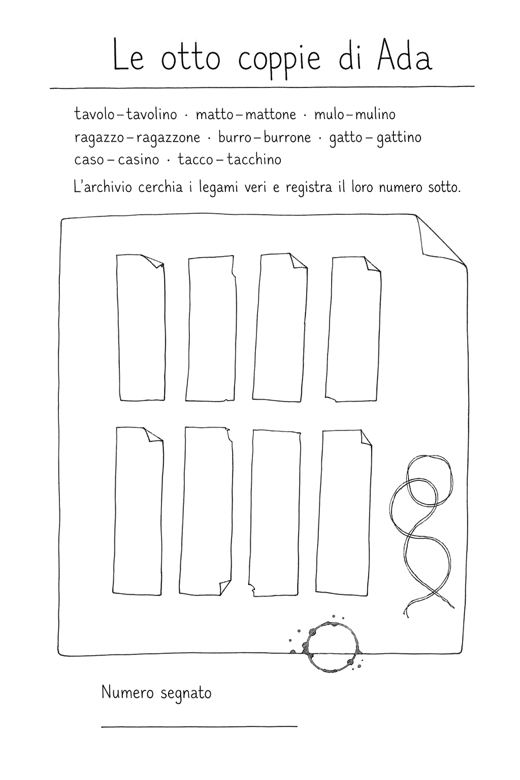


[hand_over] La carta che cambia tutto   (14 min, 29 in)
   display: Metti scheda e mappa affiancate.
   display: Abbina le coppie agli otto cerchi.
   display: Cancella la prima lettura caduta.
   display: Scrivi la decisione di Ada.
     after 4 min: I cerchi grandi occupano tre posti.
     after 8 min: Sono il primo, il quarto e il sesto.
     after 13 min: Confrontali con i tre legami veri. Poi escludi le stazioni maggiori.
     after 18 min: Ada voleva conservare sulla mappa i tre legami veri tra i nomi, prima che cambiassero.



[3] drawing a map · 43.9 s · 3211 characters sent, 24 back
--- SENT ---
The page is a hand-drawn map, the kind folded into the back of an old book: a border, a coastline or paths, and small symbols for places.

Letter this large, as the title: "La linea dei nomi perduti"
Letter this smaller, under the title: "La copia di Ada segue le otto coppie, nello stesso ordine. Il lessico conferma veri soltanto i numeri 1, 4 e 6. «Stazioni maggiori» è cancellato; resta «prima che i nomi cambino». La mappa unisce i tre cerchi e annota la decisione di Ada."
Leave one ruled line, long enough for a few words, with "Prima lettura, poi cancellata" lettered above it
Leave three ruled lines, with "Decisione di Ada" lettered above it
Leave an empty box about a third of the page high, to draw in, with "Traccia dei tre cerchi" lettered above it

What the drawing on the page shows: An old railway line curves across open country and crosses a narrow river. Eight station circles stand along the line in clear 

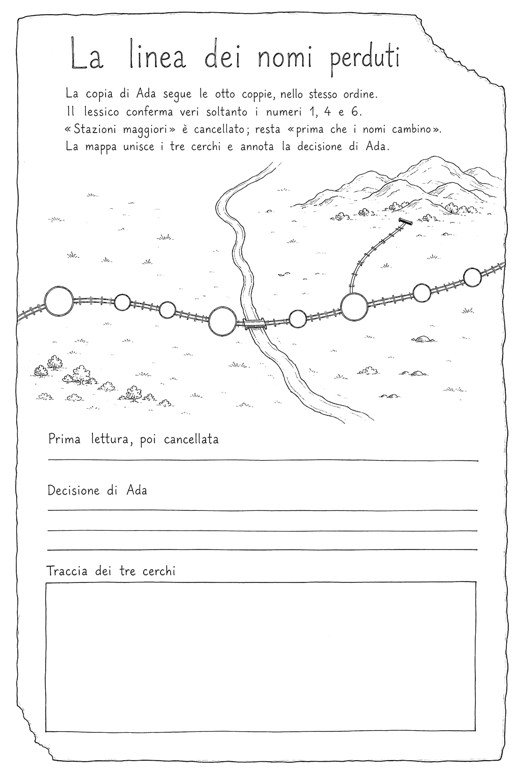


[collect] Sul vetro   (4 min, 33 in)
   display: Posa la mappa sul vetro.
   display: Tieni in alto la decisione scritta.
   display: La scheda può restare accanto.
   display: Avvia la lettura della pagina.
     after 2 min: Il vetro attende la mappa.
     after 4 min: La parte scritta resta rivolta in su.
     after 6 min: Posa e acquisisci la mappa annotata.
     after 9 min: La nota custodita dice che Ada salvava i tre legami veri dei nomi.
   way out: Carta acquisita (mappa ferroviaria)
   if marks -> ask
   if blank -> quiet-close

--- SENT to the hand, with the page above ---
The same sheet of paper, now filled in by a teenager with a blue ballpoint pen: untidy, slanted, not always on the line, a word crossed out somewhere.
Answer what the page asks, in Italian, briefly and in your own words — the way somebody of thirteen would, not the way a form would. Where there is a box to draw in, draw something rough.
Change nothing that is already printed on the page: not the title, not

   written on · 970101 bytes · tmp/pages/glass-reading-filled.png


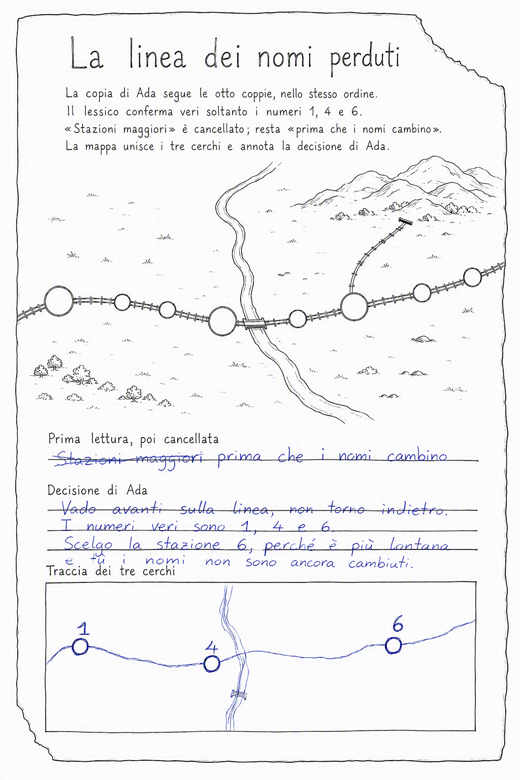


[4] reading a page against its blank · 6.4 s · 1307 characters sent, 486 back
--- SENT ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untou


[5] continuing aftn-4839fb5f after glass-reading · 10.8 s · 30855 characters sent, 21 back
--- SENT ---
You are writing the rest of an activity in one household. It was planned this far and the plan says the rest depends on what came back on paper.
Answer with JSON and nothing else, in this exact shape:
{"moments": [ ... ]}
Which activity this is and which moment it follows are known already and are not yours to write.
Every moment, whatever it does, carries these five keys and then whatever its act adds:
  "id": 2 to 32 characters of lowercase a-z, digits and hyphens. No capitals, no accented letters, no underscores and no spaces. Ids are never shown to anybody, so write them in English even when the activity is not.
  "heading": at most 28 characters, on the display.
  "weights": {"short": W, "standard": W, "extended": W} — the same moment at three costs, reaching the same point in the story. W is {"minutes": <whole number>, "lines": [a list of at most 4 lines, each at most 44 chara

In [17]:
from panel.continuing import continue_experience

BY_ID = {one.id: one for one in EXPERIENCE.moments}
ORDER = [one.id for one in EXPERIENCE.moments]
AT: str | None = ORDER[0]
MINUTES = 0
STEPS = 0
DISPLAYS: list[str] = []
SHEET = ""
IN_HAND: bytes | None = None
PAGE_ABOUT = ""

# A guard and not a rule: the moments are a graph, and a document that loops would
# otherwise walk until the money ran out.
while AT is not None and STEPS < 24:
    STEPS += 1
    MOMENT = BY_ID[AT]
    TOOK, LINES = show(MOMENT, MINUTES)
    MINUTES += TOOK
    DISPLAYS += LINES
    CAME, READ_AS = None, ""

    if isinstance(MOMENT, HandOver):
        SHEET = in_words(MOMENT.page)
        try:
            PNG, DRAWN_BY = await PageMaker().draw(CTX, MOMENT.page)
            (PAGES / f"{MOMENT.id}.png").write_bytes(PNG)
            IN_HAND, PAGE_ABOUT = PNG, MOMENT.page.title
            print(f"   printed · {len(PNG)} bytes · tmp/pages/{MOMENT.id}.png")
            seen(PNG)
        except Exception as bad:
            IN_HAND = None
            print(f"   the page did not arrive: {type(bad).__name__}: {bad}")

    if isinstance(MOMENT, Collect):
        if IN_HAND is not None:
            print(f"\n--- SENT to the hand, with the page above ---\n{asked_of(HAND)}")
            try:
                FILLED = written_on(IN_HAND, hand=HAND)
                (PAGES / f"{MOMENT.id}-filled.png").write_bytes(FILLED)
                print(f"   written on · {len(FILLED)} bytes · "
                      f"tmp/pages/{MOMENT.id}-filled.png")
                seen(FILLED)
                READING = await PageReader().read(
                    CTX,
                    blank=as_image(IN_HAND),
                    came_back=as_image(FILLED),
                    about=PAGE_ABOUT,
                )
                READ_AS = " · ".join(READING.describes)
                CAME = "marks" if READING.written else "blank"
                print(f"   read back: {CAME} · {READ_AS}")
            except Exception as bad:
                print(f"   nobody wrote on it: {type(bad).__name__}: {bad}")
        if CAME is None:
            DID = await what_they_did(
                CTX, displays=DISPLAYS, sheet=SHEET, mood=MOOD, minutes_in=MINUTES
            )
            CAME = "marks" if str(DID.get("came")) == "marks" else "blank"
            READ_AS = str(DID.get("onIt", ""))
            print(f"   the stand-in answered in words: {CAME} · {READ_AS}")
        IN_HAND = None

    AT = next_id(MOMENT, CAME)
    if AT == ASK:
        print("\n   the outcome says ask: the rest is bought here")
        MORE, SPENT = await continue_experience(
            experience=DOCUMENT,
            after=MOMENT.id,
            came=CAME,
            reading={"came": CAME, "reading": READ_AS},
            now=time.time(),
            pitch=ARGS["pitch"],
        )
        BY_ID |= {one.id: one for one in MORE.moments}
        ORDER += [one.id for one in MORE.moments]
        AT = MORE.moments[0].id
        print(f"   {len(MORE.moments)} more moments · next is {AT}")

print(f"\nover · {STEPS} moments · {MINUTES} minutes · {len(CALLS)} calls so far")


## 11. Changing a block

The blocks are the files in `agents/` and `shared/`. Edit one in the editor, run `bench.reload_prompts()`, and go back to section 4: the fingerprint changes only when the text being sent changed.

When one is settled: `python -m tools.prompts --write`, then `python -m pytest -q`, then `python -m research.run --iterations 4 --seed 0 --label <name>` — six households, four iterations, about an hour, and the eight axes are the answer to whether it improved.

⚠️ Do not run `pytest` and a run at the same time: `tests/test_trail.py` fails with `Event loop is closed` on contention, and it looks like a real regression.

In [18]:
print("fingerprint:", bench.reload_prompts())

fingerprint: 4358f1f9c9ec


## 12. The whole conversation

Every prompt and every answer, in order, in one file. Read it when an activity comes out wrong. What the answer did that nobody asked for usually points at the sentence that asked for it.

In [19]:
conversation()

[0] choosing what to build an afternoon out of     13.2 s     6452 sent      189 back
[1] devising an afternoon                         129.7 s    33652 sent    11527 back
[2] drawing a dossier                              39.3 s     2952 sent       23 back
[3] drawing a map                                  43.9 s     3211 sent       24 back
[4] reading a page against its blank                6.4 s     1307 sent      486 back
[5] continuing aftn-4839fb5f after glass-reading   10.8 s    30855 sent       21 back

6 calls · C:\code\lanternina\tmp\conversation.txt


WindowsPath('C:/code/lanternina/tmp/conversation.txt')